## File for experimenting with the effectiveness of ReLU, SiLU, and GELU activation functions


In [1]:
import tqdm
import math
import torch
import numpy as np
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set device - use CUDA if available, otherwise CPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
if device == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

raw_df = pd.read_hdf('data_files/new_Input_NonResonant_yy_25th_January2026.h5', key='VBF_Polarisation_Tree')

# Define bounds
lower_bound = 117500
upper_bound = 132500
mask1 = raw_df['HiggsM'] > upper_bound
mask2 = raw_df['HiggsM'] < lower_bound
mask3 = (raw_df['OO1'] < 5) & (raw_df['OO1'] > -5)
# Applying the bounds to the raw data for the other features
## Try applying bounds to OO1 to -10 and 10 to address distribution problem 
## Try applying a logarithmic transformation to the OO1 feature to see if it helps with the distribution issue
trimmed_df = raw_df[mask1 | mask2 & mask3]
print(trimmed_df['OO1'].describe())


# Save the trimmed DataFrame to a CSV file for inspection
# Filter out unnecessary columns and save the relevant features along with HiggsM and Frequency
features = ['DNN_score', 'DPhi_jj', 'Eta_jj', 'M_jj', 'Njets', 'OO1']
features_array = trimmed_df[features].to_numpy()
num_features = features_array.shape[1]
# print(features_array.shape)


# Array of HiggsM values for training
HiggsM_array = trimmed_df['HiggsM'].to_numpy()
# print(HiggsM_array.shape)


Using device: cpu
count    9.438274e+06
mean     2.335048e-05
std      4.454029e-01
min     -5.891569e+01
25%     -1.339945e-01
50%      1.270833e-04
75%      1.342193e-01
max      2.763301e+01
Name: OO1, dtype: float64


In [2]:
from sklearn.preprocessing import MinMaxScaler


# Normalise function
# Un-nomralise later using sampled_points_original = scaler.inverse_transform(sampled_points_normalized)
scaler_features = MinMaxScaler()
scaler_HiggsM = MinMaxScaler()

# Normalise features and HiggsM separately
features_normalised = scaler_features.fit_transform(features_array)
HiggsM_normalised = scaler_HiggsM.fit_transform(HiggsM_array.reshape(-1, 1))

### Random noise data points to start with, this is the initial distribution p0(x0), original code used random noise, replace with the Higgs tail data.


## Model

### Testing ReLU vs SiLU vs GeLU


Training with ReLU activation


ReLU training: 100%|██████████| 25000/25000 [11:48<00:00, 35.28it/s, loss=0.153] 



ReLU Results:
  Initial loss: 1.187336
  Final loss: 0.153404
  Final smoothed loss (window=100): 0.165082
  Improvement: 1.033932 (87.08%)

Training with SiLU activation


SiLU training: 100%|██████████| 25000/25000 [11:10<00:00, 37.30it/s, loss=0.198] 



SiLU Results:
  Initial loss: 1.094062
  Final loss: 0.198362
  Final smoothed loss (window=100): 0.168681
  Improvement: 0.895700 (81.87%)

Training with GELU activation


GELU training: 100%|██████████| 25000/25000 [11:44<00:00, 35.50it/s, loss=0.194] 



GELU Results:
  Initial loss: 1.269648
  Final loss: 0.193907
  Final smoothed loss (window=100): 0.170742
  Improvement: 1.075741 (84.73%)


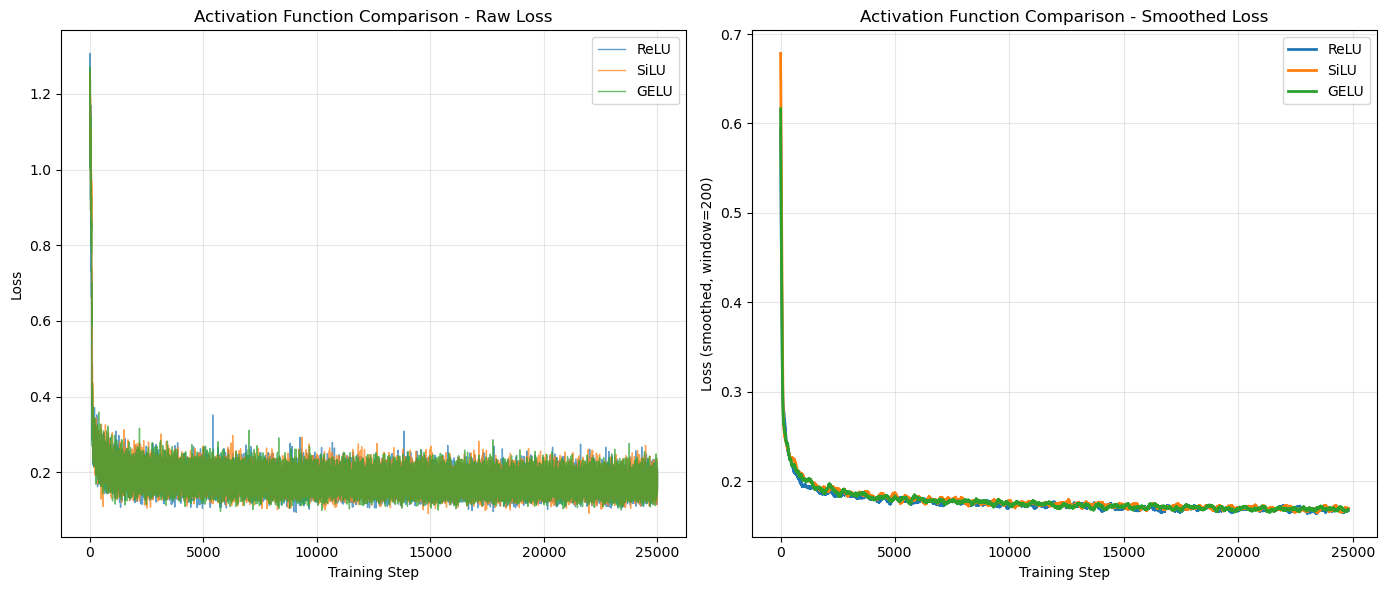


ACTIVATION FUNCTION COMPARISON SUMMARY
Activation      Initial Loss    Final Loss      Improvement %  
------------------------------------------------------------
ReLU            1.187336        0.153404        87.08          
SiLU            1.094062        0.198362        81.87          
GELU            1.269648        0.193907        84.73          


In [3]:
features_data = torch.Tensor(features_normalised).to(device)  # [N, 8] - normalized to [0, 1]
higgsM_data = torch.Tensor(HiggsM_normalised).to(device)  # [N, 1] - normalized to [0, 1]


# Flexible Block class that accepts activation function as parameter
class FlexibleBlock(nn.Module):
    def __init__(self, channels=512, activation=None):
        super().__init__()
        self.ff = nn.Linear(channels, channels)
        self.act = activation if activation is not None else nn.ReLU()
    
    def forward(self, x):
        return self.act(self.ff(x))

# Flexible ConditionalMLP that accepts activation function
class FlexibleConditionalMLP(nn.Module):
    def __init__(self, channels_data=num_features, layers=5, channels=512, channels_t=512, channels_cond=256, cond_dim=1, activation=None):
        super().__init__()
        if activation is None:
            activation = nn.ReLU()
        
        self.channels_t = channels_t
        self.channels_cond = channels_cond
        self.in_projection = nn.Linear(channels_data, channels)
        self.t_projection = nn.Linear(channels_t, channels)
        
        self.cond_projection = nn.Linear(cond_dim, channels_cond)
        self.cond_to_channels = nn.Linear(channels_cond, channels)
        
        self.blocks = nn.Sequential(*[
            FlexibleBlock(channels, activation) for _ in range(layers)
        ])
        self.out_projection = nn.Linear(channels, channels_data)

    def gen_t_embedding(self, t, max_positions=10000):
        t = t * max_positions
        half_dim = self.channels_t // 2
        emb = math.log(max_positions) / (half_dim - 1)
        emb = torch.arange(half_dim, device=t.device).float().mul(-emb).exp()
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([emb.sin(), emb.cos()], dim=1)
        if self.channels_t % 2 == 1:
            emb = nn.functional.pad(emb, (0, 1), mode='constant')
        return emb

    def forward(self, x, t, cond):
        x = self.in_projection(x)
        t = self.gen_t_embedding(t)
        t = self.t_projection(t)
        cond = self.cond_projection(cond)
        cond = self.cond_to_channels(cond)
        x = x + t + cond
        x = self.blocks(x)
        x = self.out_projection(x)
        return x

# Define activation functions to test
activations = {
    'ReLU': nn.ReLU(),
    'SiLU': nn.SiLU(),
    'GELU': nn.GELU(),
}

# Training parameters for comparison
comparison_steps = 25000
comparison_batch_size = 128

# Train models with different activations
comparison_results = {}

for act_name, activation in activations.items():
    print(f"\n{'='*60}")
    print(f"Training with {act_name} activation")
    print(f"{'='*60}")
    
    # Create model
    model_test = FlexibleConditionalMLP(
        channels_data=num_features,
        layers=5,
        channels=512,
        channels_cond=256,
        cond_dim=1,
        activation=activation
    )
    model_test = model_test.to(device)
    
    # Optimizer and scheduler
    optim_test = torch.optim.AdamW(model_test.parameters(), lr=5e-5)
    scheduler_test = torch.optim.lr_scheduler.CosineAnnealingLR(optim_test, T_max=comparison_steps)
    
    # Train
    losses_test = []
    pbar = tqdm.tqdm(range(comparison_steps), desc=f"{act_name} training")
    
    for i in pbar:
        idx = torch.randint(features_data.size(0), (comparison_batch_size,))
        x1 = features_data[idx]
        cond = higgsM_data[idx]
        x0 = torch.randn_like(x1)
        target = x1 - x0
        t = torch.rand(x1.size(0)).to(device)
        xt = (1 - t[:, None]) * x0 + t[:, None] * x1
        
        pred = model_test(xt, t, cond)
        loss = ((target - pred)**2).mean()
        
        loss.backward()
        optim_test.step()
        scheduler_test.step()
        optim_test.zero_grad()
        
        losses_test.append(loss.item())
        pbar.set_postfix(loss=loss.item())
    
    comparison_results[act_name] = losses_test
    
    # Print statistics
    final_loss = losses_test[-1]
    smoothed = np.convolve(losses_test, np.ones(100)/100, mode='valid')
    final_smoothed = smoothed[-1] if len(smoothed) > 0 else final_loss
    
    print(f"\n{act_name} Results:")
    print(f"  Initial loss: {losses_test[0]:.6f}")
    print(f"  Final loss: {final_loss:.6f}")
    print(f"  Final smoothed loss (window=100): {final_smoothed:.6f}")
    print(f"  Improvement: {(losses_test[0] - final_loss):.6f} ({100*(losses_test[0] - final_loss)/losses_test[0]:.2f}%)")

# Plot comparison
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
for act_name, losses_list in comparison_results.items():
    plt.plot(losses_list, label=act_name, alpha=0.7, linewidth=1)
plt.xlabel('Training Step')
plt.ylabel('Loss')
plt.title('Activation Function Comparison - Raw Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for act_name, losses_list in comparison_results.items():
    smoothed = np.convolve(losses_list, np.ones(200)/200, mode='valid')
    plt.plot(smoothed, label=act_name, linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Loss (smoothed, window=200)')
plt.title('Activation Function Comparison - Smoothed Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('graphs/activation_comparison.png', dpi=150)
plt.show()

# Summary table
print(f"\n{'='*60}")
print("ACTIVATION FUNCTION COMPARISON SUMMARY")
print(f"{'='*60}")
print(f"{'Activation':<15} {'Initial Loss':<15} {'Final Loss':<15} {'Improvement %':<15}")
print(f"{'-'*60}")

for act_name, losses_list in comparison_results.items():
    initial = losses_list[0]
    final = losses_list[-1]
    improvement = 100 * (initial - final) / initial
    print(f"{act_name:<15} {initial:<15.6f} {final:<15.6f} {improvement:<15.2f}")

print(f"{'='*60}")